# Edges, Corners & Structural Features

#### E/21/087 - Dewagedara D.M.E.S.

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

## Task 1 — Detect Edges Using Gradient Operators

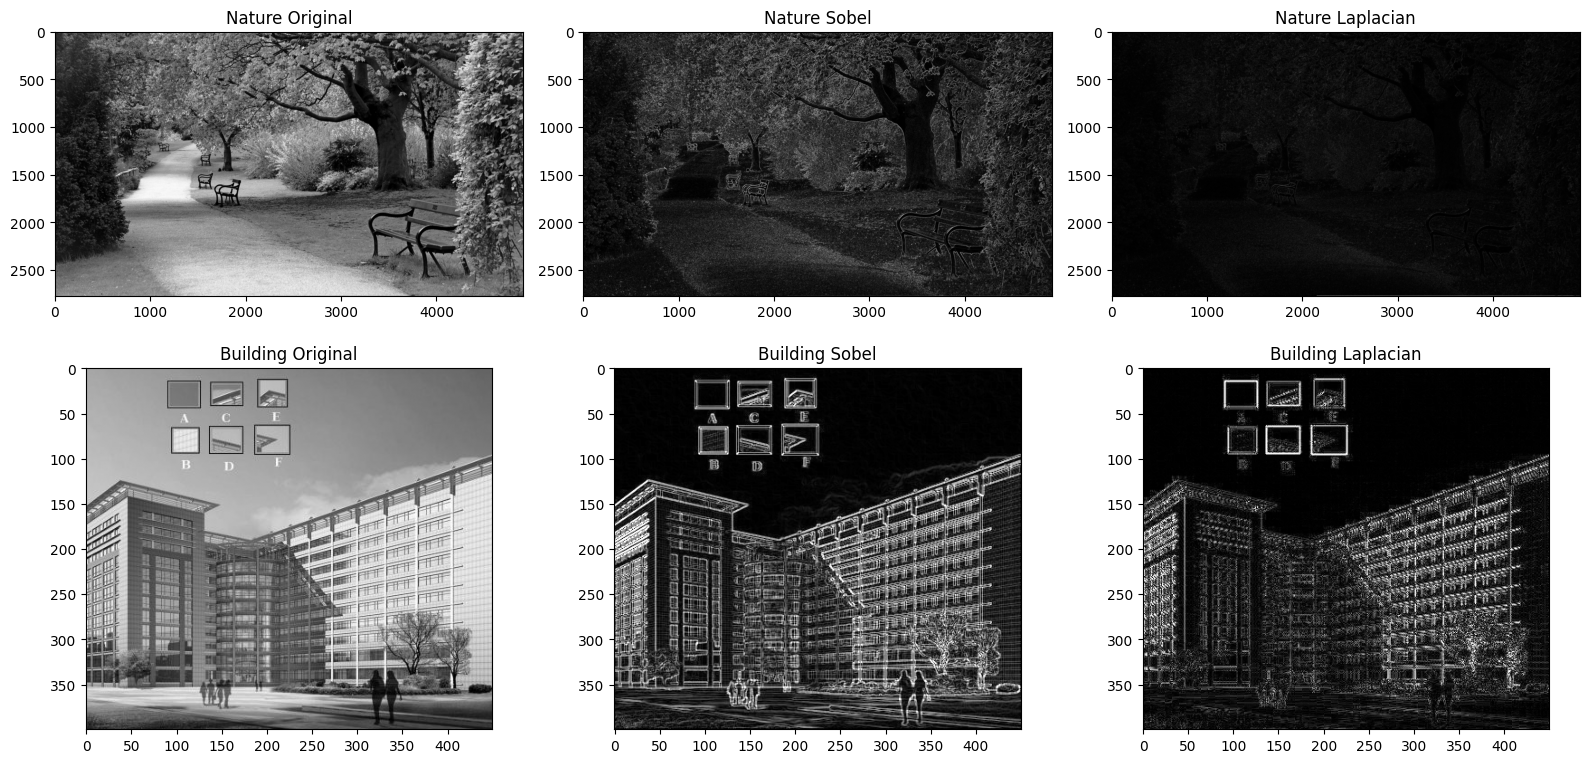

In [9]:
# Load the image
img_nature = cv2.imread('nature.jpg', cv2.IMREAD_GRAYSCALE)
img_build = cv2.imread('Sample.jpg', cv2.IMREAD_GRAYSCALE)

# Nature Image
# Apply Sobel
sobelx_n = cv2.Sobel(img_nature, cv2.CV_64F, 1, 0, ksize=3)
sobely_n = cv2.Sobel(img_nature, cv2.CV_64F, 0, 1, ksize=3)
sobel_nature = cv2.addWeighted(cv2.convertScaleAbs(sobelx_n), 0.5, cv2.convertScaleAbs(sobely_n), 0.5, 0)

# Apply Laplacian
lap_nature = cv2.Laplacian(img_nature, cv2.CV_64F)
lap_nature = cv2.convertScaleAbs(lap_nature)

# Building Image
# Apply Sobel
sobelx_b = cv2.Sobel(img_build, cv2.CV_64F, 1, 0, ksize=3)
sobely_b = cv2.Sobel(img_build, cv2.CV_64F, 0, 1, ksize=3)
sobel_build = cv2.addWeighted(cv2.convertScaleAbs(sobelx_b), 0.5, cv2.convertScaleAbs(sobely_b), 0.5, 0)

# Apply Laplacian
lap_build = cv2.Laplacian(img_build, cv2.CV_64F)
lap_build = cv2.convertScaleAbs(lap_build)

# Display Results
plt.figure(figsize=(16, 8))

# Nature Plotting
plt.subplot(2, 3, 1), plt.imshow(img_nature, cmap='gray'), plt.title('Nature Original')
plt.subplot(2, 3, 2), plt.imshow(sobel_nature, cmap='gray'), plt.title('Nature Sobel')
plt.subplot(2, 3, 3), plt.imshow(lap_nature, cmap='gray'), plt.title('Nature Laplacian')

# Building Plotting
plt.subplot(2, 3, 4), plt.imshow(img_build, cmap='gray'), plt.title('Building Original')
plt.subplot(2, 3, 5), plt.imshow(sobel_build, cmap='gray'), plt.title('Building Sobel')
plt.subplot(2, 3, 6), plt.imshow(lap_build, cmap='gray'), plt.title('Building Laplacian')

plt.tight_layout()
plt.show()

#### Answer -

##### Analysis of Operators

| Feature            | Sobel (First-Order)          | Laplacian (Second-Order)      |
|--------------------|------------------------------|-------------------------------|
| **Mathematical Basis** |  Calculates intensity gradient(slope)       | Calculates the rate of change of the gradient  |
| **Edge Appearance** | Thicker, continuous and smoother      | Thin, Fragmented and highly detailed   |
| **Sensitivity** | Moderately sensitive ; resistant to small noise    | High sensitive ; captures every minute intensity shift |
| **Visual Result** | Highlights major structural outlines         | Creates a 'skeletal' or etched effect |



##### Comparative Obervations

###### Nature Image
 - Nature Sobel: Effectively captures the broad silhouette of the tree trunk and the path. It manages to simplify the complex textures of the leaves into visible "clumps" of light and dark.
 - Nature Laplacian: Appears much darker and noisier. Because natural textures (like grass and foliage) have frequent, tiny intensity changes, the Laplacian struggles to define a single clear edge, resulting in a scattered, granular output.

###### Building 
- Building Sobel: Shows very strong, bright white lines for the main architectural pillars and windows. It excels at identifying the primary vertical and horizontal planes of the building.
- Building Laplacian: Highlights the sharpest corners and transitions. Notice the inset diagrams (A-F): the Laplacian provides a precise outline of the shapes but loses the "weight" of the edges compared to the Sobel.

##### Smoothness and Sensitivity
- **Smoothness:** The Sobel operator is significantly smoother. By calculating the first derivative, it acts as a low-pass filter to some extent, ignoring minor fluctuations to focus on significant boundaries.
- **Sensitivity:** The Laplacian is the more sensitive filter. It is an "all-or-nothing" detector that triggers on any sharp local change. This makes it excellent for finding fine details (like the individual window panes in the building) but poor for images with organic, "noisy" textures like the nature scene.

##### Conclusion
The Sobel operator is best suited for general object detection and structural outlining where noise must be suppressed. The Laplacian operator is superior for tasks requiring high-precision edge localization and fine-detail extraction, provided the input image is sufficiently clean or pre-smoothed.

### Task 2 - Detect Clean Boundaries with Canny

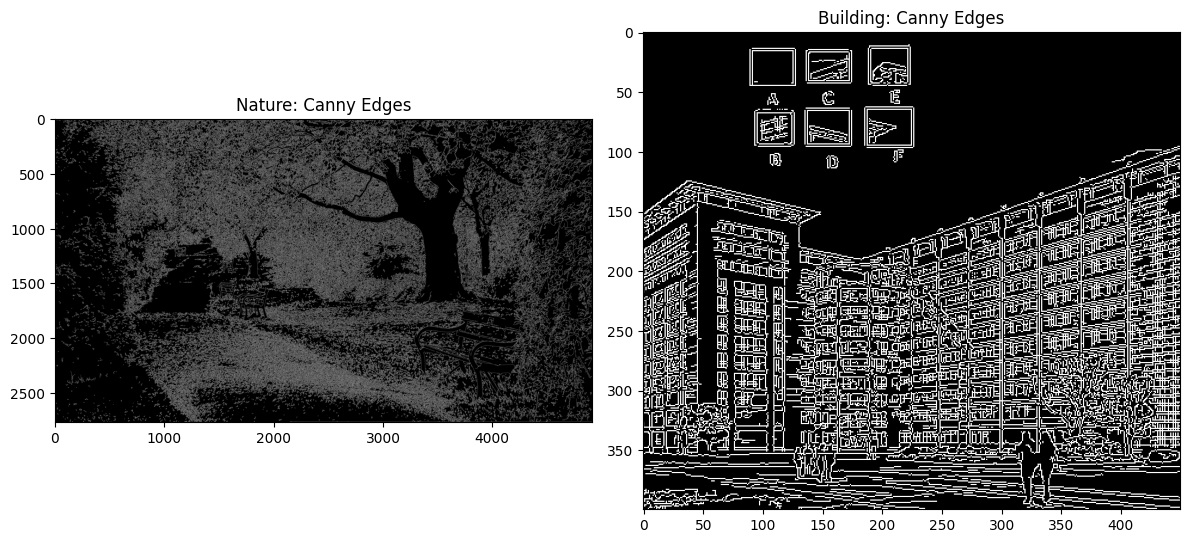

In [10]:
# Load images in Grayscale
img_nature = cv2.imread('nature.jpg', cv2.IMREAD_GRAYSCALE)
img_build = cv2.imread('Sample.jpg', cv2.IMREAD_GRAYSCALE)

# Apply Canny Edge Detection
canny_nature = cv2.Canny(img_nature, 50, 150)
canny_build = cv2.Canny(img_build, 50, 150)

# Visualization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(canny_nature, cmap='gray')
plt.title('Nature: Canny Edges')

plt.subplot(1, 2, 2)
plt.imshow(canny_build, cmap='gray')
plt.title('Building: Canny Edges')

plt.tight_layout()
plt.show()

#### Answer -

##### Why Canny edges are "Thinner"
Unlike the Sobel operator, which produces thick, blurry gradients, Canny uses a technique called Non-Maximum Suppression.

   - The algorithm looks at the gradient magnitude and direction.

   - It keeps only the local maxima and "thins" out any pixel that isn't the strongest in its immediate neighborhood.

   - This results in single-pixel wide lines that precisely locate the boundary.

##### Why Canny edges are "Cleaner"
Canny is a multi-stage pipeline. Before it even looks for edges, it applies a Gaussian blur to the image. This removes high-frequency noise that causes the "speckled" look seen in the Laplacian output.

##### Thresholds and Noise Suppression
The two numbers in the code (50 and 150) are the Hysteresis Thresholds. They work like a filter for edge "certainty":

   - High Threshold (150): Any edge with a gradient higher than this is definitely an edge (Strong edge).

   - Low Threshold (50): Any gradient below this is discarded as noise.

   - Between (50-150): These are "Candidate" edges. They are only kept if they are connected to a "Strong" edge.

| Threshold Setting           | Effect on Noise          | Effect on Edges      |
|--------------------|------------------------------|-------------------------------|
| **High Thresholds** | High noise suppression       |  Only the most prominent edges (like building outlines) appear. |
| **Low Thresholds** | Low noise suppression      | More texture is captured (like leaves), but the image becomes "messy."   |


### Task 3 — Locate Corner Features 

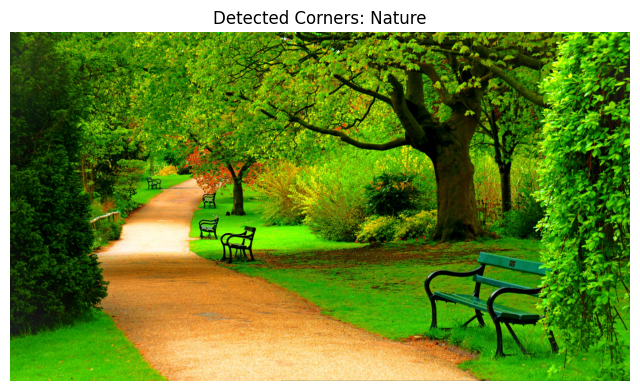

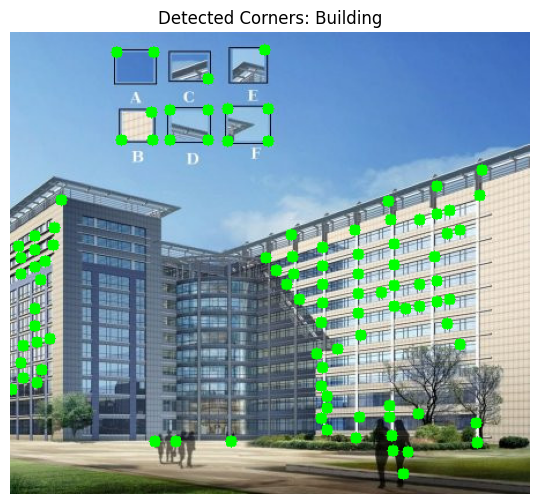

In [13]:
img_nature = cv2.imread('nature.jpg')
img_build = cv2.imread('Sample.jpg')

for img, title in [(img_nature, 'Nature'), (img_build, 'Building')]:
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect Corners
    corners = cv2.goodFeaturesToTrack(gray, 100, 0.01, 10)
    
    # Mark corners on the image
    if corners is not None:
        corners = np.intp(corners)
        for i in corners:
            x, y = i.ravel()
            cv2.circle(img, (x, y), 5, (0, 255, 0), -1)

    # Display
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Detected Corners: {title}')
    plt.axis('off')
    plt.show()

#### Answer -

##### Feature Stability
Corners are the most stable features for tracking and matching because they represent a two-dimensional change in intensity.
  - Viewpoint/Lighting: Unlike edges or flat surfaces, corners provide a unique coordinate (x, y) that remains mathematically localizable even if the camera moves or shadows shift.
  - The Aperture Problem: Edges are ambiguous; if you move along an edge, it looks the same. Corners break this ambiguity, making them "reliable landmarks."

##### Why Corners are Valuable
In the field of computer vision, corners are the preferred feature for matching (linking two different images) and tracking (following a point through a video) for the following reasons:

| Reason           | Explanation          |
|--------------------|------------------------------|
| **Unambiguous Localization** |Unlike edges, which suffer from the "Aperture Problem" (movement along the edge is invisible), a corner's movement is distinct in all directions.      |
| **Reduced Data Complexity** | Instead of analyzing every pixel in your high-resolution nature image, you only need to track a few dozen "high-quality" corner points to understand the camera's motion.     |
| **Robust Matching** | When stitching a panorama, corners provide the "anchors" that allow the computer to align the building's windows or a tree's branches perfectly.    |

##### Observations
 - **Building:** Corners are found on windows and rooflines. These are rigid and highly reliable for tracking.

 - **Nature:** Corners appear on leaf tips and branch intersections. These are less stable because they can move with the wind (non-rigid motion).

### Task 4 — Extract Dominant Lines

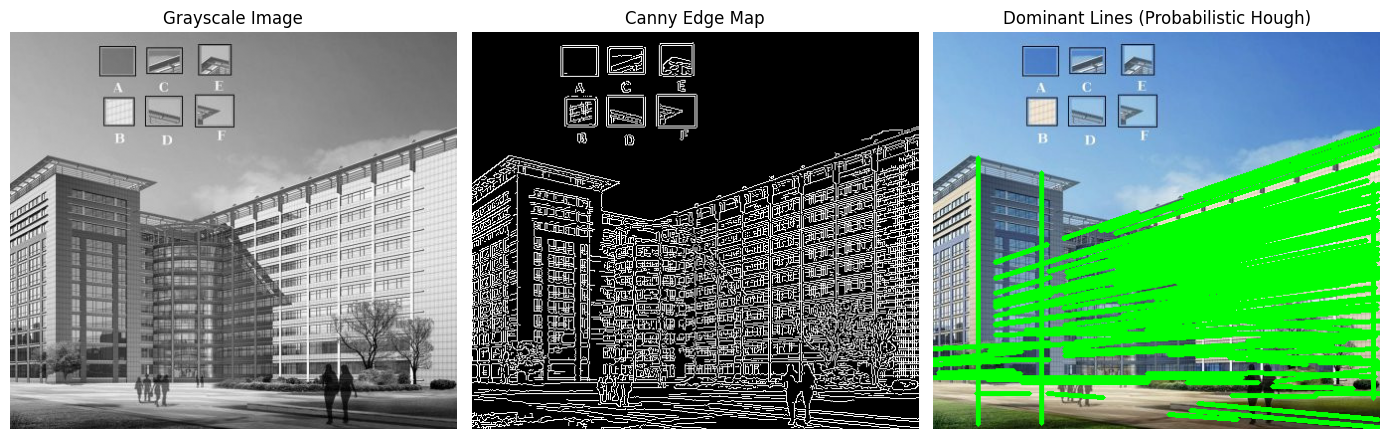

In [18]:
# Load image
img = cv2.imread("Sample.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Canny Edge Detection
edges_building = cv2.Canny(gray, 50, 150)

# Probabilistic Hough Transform
lines = cv2.HoughLinesP(
    edges_building,
    rho=1,
    theta=np.pi / 180,
    threshold=150,
    minLineLength=50,
    maxLineGap=10
)

# Draw Detected Lines
img_lines = img.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 3)

# Display Results
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges_building, cmap='gray')
plt.title("Canny Edge Map")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
plt.title("Dominant Lines (Probabilistic Hough)")
plt.axis('off')

plt.tight_layout()
plt.show()


#### Answer - 

##### Dominant Line Analysis

The Hough Transform is particularly effective at isolating man-made geometry because human-built environments are defined by regularity and linear patterns.

  - **Structural Representation:** In building output, the detected green lines align perfectly with the horizontal window rows and vertical structural columns. This demonstrates how the algorithm translates raw edge pixels into global geometric models.

  - **Parallelism and Orthogonality:** The transform highlights the parallel nature of the building's stories. While nature (leaves/trees) produces fragmented, irregular edges, man-made structures provide the long, continuous "votes" necessary for the algorithm to identify a dominant line.

  - **Filtering Chaos:** Notice how the organic shapes (the trees at the bottom) do not have many green lines. The Hough Transform effectively "ignores" the chaotic edges of nature to focus on the mathematical order of the architecture.


##### The Effect of the Vote Threshold
The threshold parameter is the quality control for your line detection. It dictates how many edge pixels must align perfectly before the algorithm declares a "line" exists.

| Threshold Level          | Visual Result          | Impact on Report      |
|--------------------|------------------------------|-------------------------------|
| **High Thresholds** | Fewer, longer lines.       |  Pros: Only the most certain structural features (like the roofline) are kept. Cons: You might miss smaller architectural details. |
| **Low Thresholds** | Many short, scattered lines.     | Pros: Detects subtle details. Cons: Becomes "noisy," as it may start misidentifying tree branches or small textures as straight lines.   |

### Final Reflection

Structural cues—namely edges, corners, and lines—serve as the geometric "DNA" of an image, providing the fundamental landmarks necessary for complex computer vision tasks. Edges and lines, as seen in Hough Transform results, define the global orientation and boundaries of objects, which is essential for stitching multiple photos into a seamless panorama by aligning overlapping linear structures. Corners provide the unique, localized points that are highly stable across different viewpoints, making them the "anchor points" for object tracking and mapping; because a corner can be precisely pinpointed in 2D space, an algorithm can follow these specific coordinates from frame to frame to calculate a camera’s path or an object's motion. Together, these features allow a machine to transform a raw grid of pixels into a structured spatial model where man-made regularity and natural geometry can be identified, matched, and followed in real-time.